# Void identification in a hyperelastic plate
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/optimization/planar/void_identification.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/optimization/planar/void_identification.ipynb)

We solve an *inverse* problem: an elliptical void is hidden inside a Neo-Hookean plate and we recover its position, size, and orientation from displacements measured on the outer boundary alone.

This is case 1 of [Zhang et al., *Analyses of internal structures and defects in materials using physics-informed neural networks*, Science Advances 8, eabk0644 (2022)](https://doi.org/10.1126/sciadv.abk0644), which identified the same five parameters with a PINN. Here the forward model is a finite element solve and the parameters are recovered by differentiating straight through it.

## Problem setup

A unit square of Neo-Hookean material in plane strain is pulled by opposing uniaxial tractions $P_0$ on its left and right edges. Rigid body motion is removed the way the paper does it, by pinning the bottom left corner and supporting the bottom right corner on a roller. Somewhere inside sits an elliptical void described by five unknowns

$$\theta = (X_1^c, X_2^c, A, B, \Gamma),$$

its center, its two semi-axes, and the angle between the semi-axis $A$ and the $X_1$ axis. The values below are the reference values of the paper.


In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np
import pygmsh
import torch
from scipy.interpolate import griddata

from torchfem import Planar
from torchfem.materials import HyperelasticPlaneStrain
from torchfem.mesh import rect_quad

torch.set_default_dtype(torch.float64)

In [2]:
# Plate edge length and applied traction
L = 1.0
P0 = 0.1

# Neo-Hookean parameters of the solid
MU = 0.333
KAPPA = 10 * MU

# The void we are looking for
XC, YC, A, B, GAMMA = 0.05, 0.10, 0.35, 0.15, np.deg2rad(-30.0)
THETA = torch.tensor([XC, YC, A, B, GAMMA])

# Load increments of the finite strain solve
increments = torch.linspace(0.0, 1.0, 11)

The paper uses an incompressible Neo-Hookean solid with 

$$\psi = \frac{\mu}{2} (\textrm{tr}(\mathbf{C}) - 3) .$$

*Torch-fem* has no mixed element to enforce $J=1$ exactly, so incompressibility is approached with a penalty on the volumetric part,

$$\psi(\mathbf{C}) = \frac{\mu}{2} \left(\textrm{tr}(\bar{\mathbf{C}}) - 3\right) + \frac{\kappa}{2} \left(J-1\right)^2, \qquad \bar{\mathbf{C}} = J^{-\frac{2}{3}} \mathbf{C},$$

with $\kappa \gg \mu$.

In [3]:
def psi(F, params):
    """Nearly incompressible Neo-Hookean strain energy density function."""
    mu, kappa = params[0], params[1]
    C = F.transpose(-1, -2) @ F
    J = torch.exp(0.5 * torch.logdet(C))
    C_bar = C * J ** (-2.0 / 3.0)
    return mu / 2 * (torch.trace(C_bar) - 3.0) + kappa / 2 * (J - 1) ** 2

In [4]:
# Identification mesh: a structured quad mesh that ignores the void entirely
N = 48
nodes, elements = rect_quad(N + 1, N + 1, L, L)
nodes -= L / 2
h = L / N
centroids = nodes[elements].mean(dim=1)
model = Planar(nodes, elements, HyperelasticPlaneStrain(psi, params=[MU, KAPPA]))

left = nodes[:, 0] < -L / 2 + 1e-9
right = nodes[:, 0] > L / 2 - 1e-9
bottom = nodes[:, 1] < -L / 2 + 1e-9

# Pinned bottom left corner and roller support at the bottom right corner
model.constraints[bottom & left] = True
model.constraints[bottom & right, 1] = True

# Uniaxial traction on the left and right edge
model.forces = model.integrate_line_load(right, torch.tensor([P0, 0.0]))
model.forces += model.integrate_line_load(left, torch.tensor([-P0, 0.0]))

## Ground truth

The observations must not come from the model that is fitted later, or the inverse problem is solved on data it cannot help but reproduce. The reference is therefore built with `pygmsh`: a body-fitted mesh of quadratic triangles around a *real* hole.

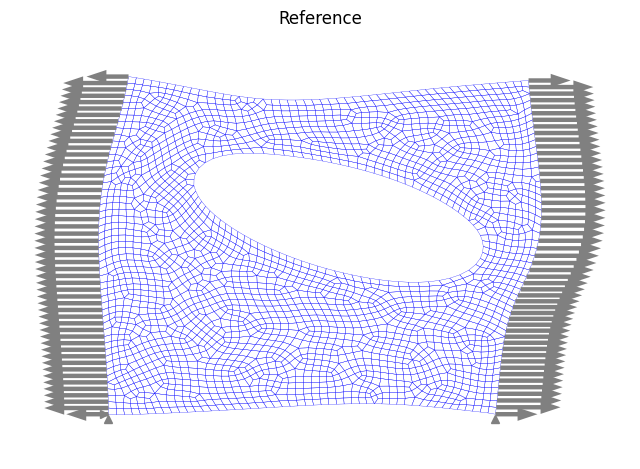

In [5]:
with pygmsh.occ.Geometry() as geom:
    geom.characteristic_length_max = 0.02
    plate = geom.add_rectangle([-L / 2, -L / 2, 0.0], a=L, b=L)
    hole = geom.add_disk([XC, YC, 0.0], A, B)
    geom.rotate(hole, (XC, YC, 0.0), GAMMA, (0.0, 0.0, 1.0))
    surfaces = geom.boolean_difference(plate, hole)
    geom.set_recombined_surfaces(surfaces)
    mesh = geom.generate_mesh(order=1)

reference = Planar(
    torch.from_numpy(mesh.points[:, :2]),
    torch.from_numpy(mesh.cells_dict["quad"].astype(np.int64)),
    HyperelasticPlaneStrain(psi, params=[MU, KAPPA]),
)

left = reference.nodes[:, 0] < -L / 2 + 1e-9
right = reference.nodes[:, 0] > L / 2 - 1e-9
bottom = reference.nodes[:, 1] < -L / 2 + 1e-9

# Pinned bottom left corner and roller support at the bottom right corner
reference.constraints[bottom & left] = True
reference.constraints[bottom & right, 1] = True

# Uniaxial traction on the left and right edge
reference.forces += reference.integrate_line_load(right, torch.tensor([P0, 0.0]))
reference.forces += reference.integrate_line_load(left, torch.tensor([-P0, 0.0]))

u_ref, *_ = reference.solve(increments=increments, nlgeom=True)

reference.plot(u=u_ref, linewidth=0.2, title="Reference", color="blue")

Displacements are measured at ten points per edge, the layout of the paper, which leaves 36 sensors once the shared corners are counted once. The sensors sit at nodes of the identification mesh built below, and the reference solution is interpolated onto them.


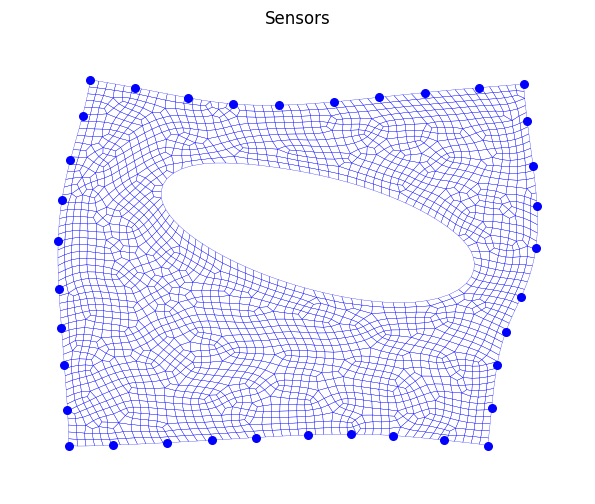

In [6]:
# Ten measurement points per edge, as in the paper
t = torch.linspace(-L / 2, L / 2, 10)
e = torch.full_like(t, L / 2)
targets = torch.cat(
    [
        torch.stack([-e, t], dim=1),  # left
        torch.stack([e, t], dim=1),  # right
        torch.stack([t, -e], dim=1),  # bottom
        torch.stack([t, e], dim=1),  # top
    ]
)
sensors = torch.cdist(targets, nodes).argmin(dim=1).unique()

# Interpolate the reference displacement onto the sensor positions
u_obs = torch.from_numpy(griddata(reference.nodes, u_ref, nodes[sensors]))

reference.plot(u=u_ref, bcs=False, linewidth=0.2, title="Sensors", color="blue")
plt.scatter(*(nodes[sensors] + u_obs).T, s=30, color="blue", zorder=3)
plt.show()

## Geometry projection

The identification mesh has no hole in it. The void is *projected* onto it instead: every element gets a density $\rho \in [0,1]$ from a smoothed indicator of the ellipse,

$$\rho(\theta) = \textrm{sig}\left(\frac{r-1}{\epsilon}\sqrt{AB}\right), \qquad r^2 = \left(\frac{p_1}{A}\right)^2 + \left(\frac{p_2}{B}\right)^2,$$

where $\mathbf{p}$ is the element centroid in the frame of the ellipse and $\epsilon$ sets the width of the transition band. The material parameters are scaled by $\rho$ down to a small residual stiffness, as in a SIMP topology optimization.

The point of the projection is that $\rho$ is a smooth function of all five parameters. No remeshing is needed and the gradient of any response with respect to $\theta$ follows from the chain rule.

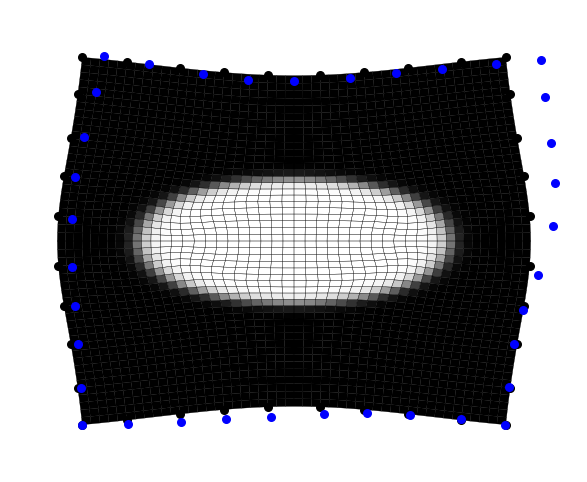

In [7]:
# Residual stiffness of the void and width of the transition band
VOID = 1e-3
EPS = 0.5 * h

# Set inial guess for the ellipse parameters
theta = torch.tensor([0.0, 0.0, 0.30, 0.20, 0.0], requires_grad=True)


def density(theta):
    """Smoothed indicator of the material outside the ellipse."""
    xc, yc, a, b, gamma = theta
    c, s = torch.cos(gamma), torch.sin(gamma)
    dx, dy = centroids[:, 0] - xc, centroids[:, 1] - yc
    p1, p2 = c * dx + s * dy, -s * dx + c * dy
    r = torch.sqrt((p1 / a) ** 2 + (p2 / b) ** 2 + 1e-12)
    return torch.sigmoid((r - 1.0) * (a * b).abs().sqrt() / EPS)


params = (VOID + (1 - VOID) * density(theta))[:, None] * torch.tensor([MU, KAPPA])
model.material.params = params
u, *_ = model.solve(increments=increments, nlgeom=True)

model.plot(
    u=u, element_property=density(theta), cmap="gray_r", bcs=False, linewidth=0.2
)
plt.scatter(*(nodes[sensors] + u[sensors]).T, s=30, color="black", zorder=3)
plt.scatter(*(nodes[sensors] + u_obs).T, s=30, color="blue", zorder=3)
plt.show()

## Identification

The objective is the squared misfit between computed and measured sensor displacements,

$$f(\theta) = \sum_i \lVert \mathbf{u}_i(\theta) - \mathbf{u}_i^* \rVert^2,$$

minimized with L-BFGS. Each closure call is one incremental finite strain solve and a backward pass through it, where `differentiable_parameters` carries the gradient through the implicit Newton iterations.

The step size needs care. At the default `lr` the line search probes wildly on its first step, and a void that reaches a loaded edge or degenerates to a negative semi-axis leaves the Newton solve nothing to converge to. Shortening the step keeps every probe inside the plate.

The initial guess is a centered, mildly elongated ellipse. It must not be a circle: for $A = B$ the response does not depend on $\Gamma$, so the orientation would start with a vanishing gradient.

In [8]:
def observe(theta):
    """Sensor displacements for a void described by theta."""
    params = (VOID + (1 - VOID) * density(theta))[:, None] * torch.tensor([MU, KAPPA])
    model.material.params = params
    u, *_ = model.solve(
        increments=increments, nlgeom=True, differentiable_parameters=params
    )
    return u[sensors]


# A short step keeps the line search from probing voids that leave the plate
optimizer = torch.optim.LBFGS(
    [theta], lr=0.05, max_iter=60, line_search_fn="strong_wolfe"
)
losses = []


def closure():
    optimizer.zero_grad()
    loss = ((observe(theta) - u_obs) ** 2).sum()
    loss.backward()
    losses.append(loss.item())
    return loss


optimizer.step(closure)

tensor(0.0940, grad_fn=<SumBackward0>)

## Results

In [9]:
identified = theta.detach()
print(f"{'':6s}{'identified':>12s}{'reference':>12s}{'error':>10s}")
for name, i, r in zip(["X1c", "X2c", "A", "B", "Gamma"], identified, THETA):
    scale = 180 / torch.pi if name == "Gamma" else 1.0
    print(f"{name:6s}{scale * i:12.4f}{scale * r:12.4f}{scale * (i - r):+10.4f}")

        identified   reference     error
X1c         0.0495      0.0500   -0.0005
X2c         0.1002      0.1000   +0.0002
A           0.3588      0.3500   +0.0088
B           0.1468      0.1500   -0.0032
Gamma     -30.4444    -30.0000   -0.4444


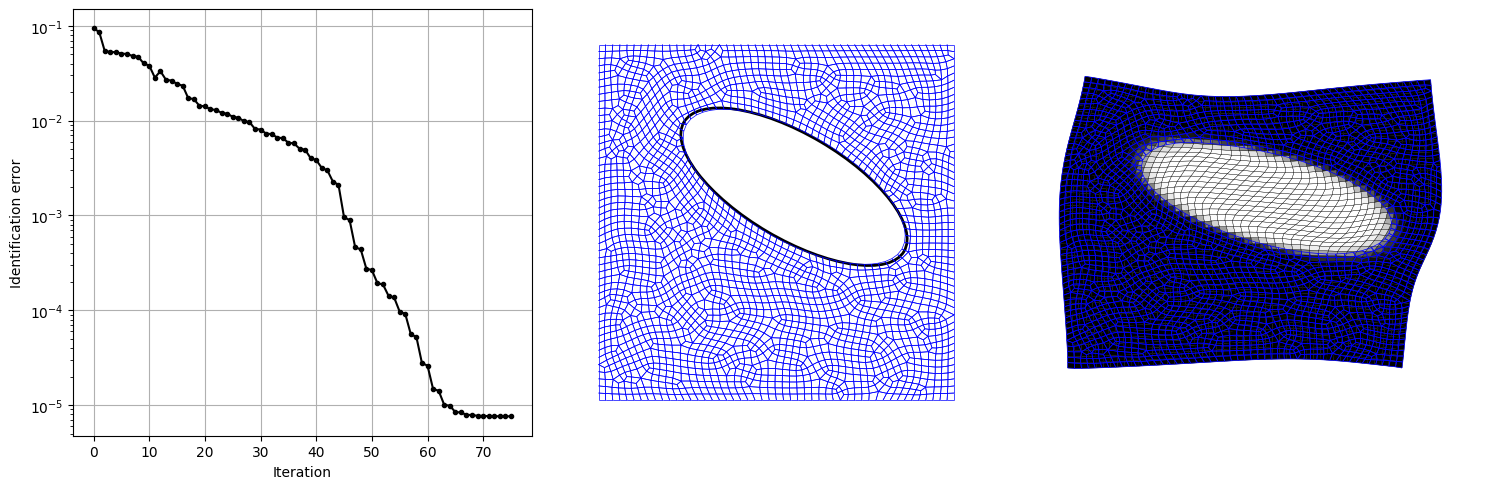

In [10]:
# Compute the final displacement field for the identified void
params = (VOID + (1 - VOID) * density(theta))[:, None] * torch.tensor([MU, KAPPA])
model.material.params = params
u, *_ = model.solve(increments=increments, nlgeom=True)


fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Convergence of the identification error
ax[0].semilogy(losses, ".-k")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Identification error")
ax[0].grid()

# Undeformed meshes
reference.plot(bcs=False, linewidth=0.5, ax=ax[1], color="blue")
xc, yc, a, b, gamma = identified.tolist()
ax[1].add_patch(
    Ellipse(
        (xc, yc),
        2 * a,
        2 * b,
        angle=gamma * 180 / torch.pi,
        edgecolor="black",
        facecolor="none",
        lw=2.0,
    )
)

# Deformed meshes
model.plot(
    u=u,
    element_property=density(identified),
    bcs=False,
    linewidth=0.2,
    cmap="gray_r",
    ax=ax[2],
)
reference.plot(u=u_ref, bcs=False, linewidth=0.5, color="blue", ax=ax[2])

plt.tight_layout()
plt.show()